### Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

#### Load Dataset

In [3]:
df=pd.read_csv(r"C:\Users\LENOVO\Downloads\indian_roads_dataset.csv")
df

,accident_id,city,state,latitude,longitude,date,time,hour,day_of_week,is_weekend,...,visibility,temperature,traffic_density,cause,accident_severity,vehicles_involved,casualties,is_peak_hour,festival,risk_score
0,0,Pune,Maharashtra,18.680827,73.930388,2023-10-22,5:00,5,Sunday,1,...,low,32,high,weather,fatal,2,2,0,NaN,0.85
1,1,Mumbai,Maharashtra,18.817732,72.790846,2023-05-21,4:00,4,Sunday,1,...,high,34,low,weather,major,4,3,0,NaN,0.10
2,2,Mumbai,Maharashtra,19.096889,72.819424,2024-07-10,13:00,13,Wednesday,0,...,low,21,medium,weather,minor,1,1,0,NaN,0.45
3,3,Chandigarh,Punjab,30.787805,76.847507,2025-03-30,11:00,11,Sunday,1,...,low,30,high,distraction,minor,5,2,0,NaN,0.65
4,4,Chennai,Tamil Nadu,12.965155,80.283313,2024-01-25,16:00,16,Thursday,0,...,high,24,low,distraction,minor,2,1,0,NaN,0.10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,19995,Bangalore,Karnataka,13.092276,77.599571,2022-09-29,3:00,3,Thursday,0,...,high,31,low,distraction,minor,3,2,0,NaN,0.10
19996,19996,Chennai,Tamil Nadu,13.172928,80.157062,2023-11-25,1:00,1,Saturday,1,...,high,20,low,distraction,major,4,2,0,NaN,0.10
19997,19997,Chennai,Tamil Nadu,12.997170,80.150724,2022-06-18,15:00,15,Saturday,1,...,high,22,low,weather,minor,3,3,0,NaN,0.10
19998,19998,Kolkata,West Bengal,22.454882,88.322213,2023-03-12,4:00,4,Sunday,1,...,high,33,low,poor road,minor,1,0,0,NaN,0.10


# 🚦 Smart Road Safety Analytics & Risk Assessment System

## About Dataset

This dataset provides a comprehensive view of road accidents across major Indian cities between 2022–2025. It combines traffic conditions, weather, road infrastructure, and temporal patterns to create a machine learning–ready dataset.

---

## 🌍 Cities Covered
Delhi, Mumbai, Chandigarh, Bangalore, Kolkata, Hyderabad, Chennai, Pune

---

## 📋 Features Included

### 🚗 Accident Information
- Accident severity — minor, major, fatal
- Number of vehicles involved
- Casualties

### 📍 Geospatial Data
- Latitude and Longitude
- City and State

### ⏱️ Temporal Features
- Date and Time
- Hour of the day
- Day of the week
- Weekend indicator
- Peak hour indicator

### 🌦️ Environmental Factors
- Weather conditions — clear, rain, fog
- Visibility levels
- Temperature

### 🛣️ Road & Traffic Conditions
- Road type — highway, urban, rural
- Number of lanes
- Traffic signal presence
- Traffic density

### 🎉 Contextual Factors
- Festival indicators — Diwali, Holi, Eid, etc.

### ⭐ Engineered Feature
- **Risk Score (0–1):** A composite indicator representing accident risk based on traffic, weather, visibility, and time conditions

---

## 💡 Use Cases
- Accident severity prediction
- Risk analysis and hotspot detection
- Traffic pattern analysis
- Smart city planning
- Geospatial and time-series modeling

---



### EDA (Exploratory Data Analysis)

In [3]:
df.size

480000

In [4]:
df.shape

(20000, 24)

In [5]:
df.columns

Index(['accident_id', 'city', 'state', 'latitude', 'longitude', 'date', 'time',
       'hour', 'day_of_week', 'is_weekend', 'road_type', 'lanes',
       'traffic_signal', 'weather', 'visibility', 'temperature',
       'traffic_density', 'cause', 'accident_severity', 'vehicles_involved',
       'casualties', 'is_peak_hour', 'festival', 'risk_score'],
      dtype='object')

In [6]:
df.dtypes

accident_id            int64
city                  object
state                 object
latitude             float64
longitude            float64
date                  object
time                  object
hour                   int64
day_of_week           object
is_weekend             int64
road_type             object
lanes                  int64
traffic_signal         int64
weather               object
visibility            object
temperature            int64
traffic_density       object
cause                 object
accident_severity     object
vehicles_involved      int64
casualties             int64
is_peak_hour           int64
festival              object
risk_score           float64
dtype: object

In [7]:
df.head()

,accident_id,city,state,latitude,longitude,date,time,hour,day_of_week,is_weekend,...,visibility,temperature,traffic_density,cause,accident_severity,vehicles_involved,casualties,is_peak_hour,festival,risk_score
0,0,Pune,Maharashtra,18.680827,73.930388,2023-10-22,5:00,5,Sunday,1,...,low,32,high,weather,fatal,2,2,0,NaN,0.85
1,1,Mumbai,Maharashtra,18.817732,72.790846,2023-05-21,4:00,4,Sunday,1,...,high,34,low,weather,major,4,3,0,NaN,0.10
2,2,Mumbai,Maharashtra,19.096889,72.819424,2024-07-10,13:00,13,Wednesday,0,...,low,21,medium,weather,minor,1,1,0,NaN,0.45
3,3,Chandigarh,Punjab,30.787805,76.847507,2025-03-30,11:00,11,Sunday,1,...,low,30,high,distraction,minor,5,2,0,NaN,0.65
4,4,Chennai,Tamil Nadu,12.965155,80.283313,2024-01-25,16:00,16,Thursday,0,...,high,24,low,distraction,minor,2,1,0,NaN,0.10


In [8]:
df.tail()

,accident_id,city,state,latitude,longitude,date,time,hour,day_of_week,is_weekend,...,visibility,temperature,traffic_density,cause,accident_severity,vehicles_involved,casualties,is_peak_hour,festival,risk_score
19995,19995,Bangalore,Karnataka,13.092276,77.599571,2022-09-29,3:00,3,Thursday,0,...,high,31,low,distraction,minor,3,2,0,NaN,0.10
19996,19996,Chennai,Tamil Nadu,13.172928,80.157062,2023-11-25,1:00,1,Saturday,1,...,high,20,low,distraction,major,4,2,0,NaN,0.10
19997,19997,Chennai,Tamil Nadu,12.997170,80.150724,2022-06-18,15:00,15,Saturday,1,...,high,22,low,weather,minor,3,3,0,NaN,0.10
19998,19998,Kolkata,West Bengal,22.454882,88.322213,2023-03-12,4:00,4,Sunday,1,...,high,33,low,poor road,minor,1,0,0,NaN,0.10
19999,19999,Delhi,Delhi,28.510266,77.065301,2024-07-05,23:00,23,Friday,0,...,low,39,high,overspeeding,minor,4,2,0,NaN,0.65


In [9]:
df.sample(5)

,accident_id,city,state,latitude,longitude,date,time,hour,day_of_week,is_weekend,...,visibility,temperature,traffic_density,cause,accident_severity,vehicles_involved,casualties,is_peak_hour,festival,risk_score
9372,9372,Bangalore,Karnataka,12.908289,77.778186,2023-01-01,20:00,20,Sunday,1,...,low,21,medium,drunk driving,minor,4,0,0,New Year,0.55
8946,8946,Hyderabad,Telangana,17.583129,78.210281,2023-07-06,17:00,17,Thursday,0,...,low,36,high,drunk driving,minor,2,0,1,NaN,0.80
7035,7035,Mumbai,Maharashtra,19.113078,72.830184,2025-01-10,19:00,19,Friday,0,...,high,17,high,poor road,fatal,2,2,1,NaN,0.65
11125,11125,Pune,Maharashtra,18.427033,73.823269,2024-10-07,5:00,5,Monday,0,...,low,24,high,overspeeding,minor,1,0,0,NaN,0.65
6435,6435,Chennai,Tamil Nadu,12.888962,80.116751,2023-08-10,14:00,14,Thursday,0,...,low,17,medium,poor road,minor,1,0,0,NaN,0.45


In [10]:
df.mean(numeric_only=True)

accident_id          9999.500000
latitude               20.389207
longitude              78.173330
hour                   11.487200
is_weekend              0.286150
lanes                   3.493950
traffic_signal          0.499850
temperature            27.579600
vehicles_involved       2.992000
casualties              1.726450
is_peak_hour            0.247400
risk_score              0.437585
dtype: float64

In [11]:
df.describe()

,accident_id,latitude,longitude,hour,is_weekend,lanes,traffic_signal,temperature,vehicles_involved,casualties,is_peak_hour,risk_score
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,9999.500000,20.389207,78.173330,11.487200,0.286150,3.493950,0.499850,27.579600,2.992000,1.726450,0.247400,0.437585
std,5773.647028,6.165791,4.485967,6.945563,0.451972,1.705406,0.500012,7.454746,1.415534,1.489104,0.431512,0.218130
min,0.000000,12.800172,72.700017,0.000000,0.000000,1.000000,0.000000,15.000000,1.000000,0.000000,0.000000,0.100000
25%,4999.750000,13.198653,73.997979,5.000000,0.000000,2.000000,0.000000,21.000000,2.000000,1.000000,0.000000,0.250000
50%,9999.500000,18.812008,77.297000,12.000000,0.000000,4.000000,0.000000,28.000000,3.000000,1.000000,0.000000,0.450000
75%,14999.250000,28.402467,80.111089,18.000000,1.000000,5.000000,1.000000,34.000000,4.000000,3.000000,0.000000,0.600000
max,19999.000000,30.799960,88.499861,23.000000,1.000000,6.000000,1.000000,40.000000,5.000000,5.000000,1.000000,1.000000


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   accident_id        20000 non-null  int64  
 1   city               20000 non-null  object 
 2   state              20000 non-null  object 
 3   latitude           20000 non-null  float64
 4   longitude          20000 non-null  float64
 5   date               20000 non-null  object 
 6   time               20000 non-null  object 
 7   hour               20000 non-null  int64  
 8   day_of_week        20000 non-null  object 
 9   is_weekend         20000 non-null  int64  
 10  road_type          20000 non-null  object 
 11  lanes              20000 non-null  int64  
 12  traffic_signal     20000 non-null  int64  
 13  weather            20000 non-null  object 
 14  visibility         20000 non-null  object 
 15  temperature        20000 non-null  int64  
 16  traffic_density    200

In [13]:
df.isnull().sum() 

accident_id              0
city                     0
state                    0
latitude                 0
longitude                0
date                     0
time                     0
hour                     0
day_of_week              0
is_weekend               0
road_type                0
lanes                    0
traffic_signal           0
weather                  0
visibility               0
temperature              0
traffic_density          0
cause                    0
accident_severity        0
vehicles_involved        0
casualties               0
is_peak_hour             0
festival             19885
risk_score               0
dtype: int64

In [14]:
df['festival'].fillna('Unknown', inplace=True)
df.isnull().sum()

accident_id          0
city                 0
state                0
latitude             0
longitude            0
date                 0
time                 0
hour                 0
day_of_week          0
is_weekend           0
road_type            0
lanes                0
traffic_signal       0
weather              0
visibility           0
temperature          0
traffic_density      0
cause                0
accident_severity    0
vehicles_involved    0
casualties           0
is_peak_hour         0
festival             0
risk_score           0
dtype: int64

In [15]:
df_cleaned = df.dropna()

In [16]:
df['accident_severity'].value_counts()

accident_severity
minor    11025
major     5988
fatal     2987
Name: count, dtype: int64

### Visualization

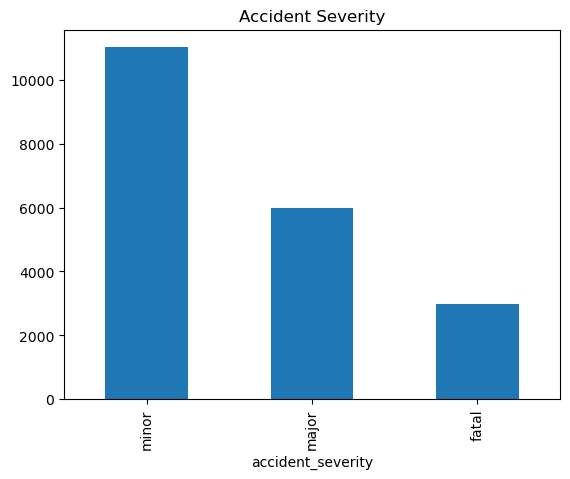

In [17]:
# bar plot
df['accident_severity'].value_counts().plot(kind='bar')
plt.title('Accident Severity')
plt.show()

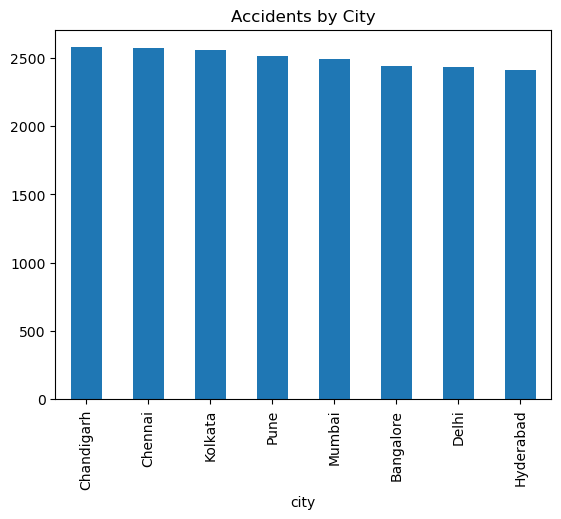

In [18]:
df['city'].value_counts().plot(kind='bar')
plt.title('Accidents by City')
plt.show()

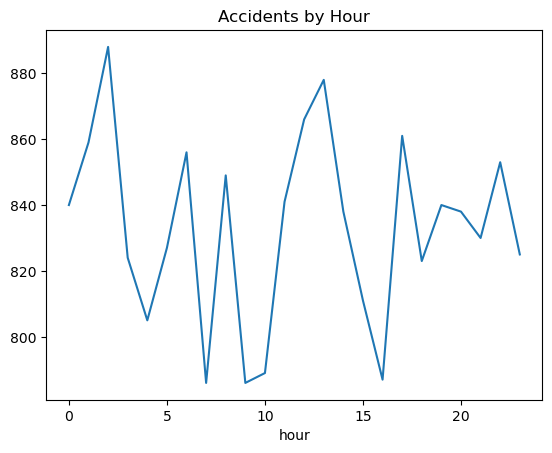

In [19]:
#line plot
df['hour'].value_counts().sort_index().plot(kind='line')
plt.title('Accidents by Hour')
plt.show()

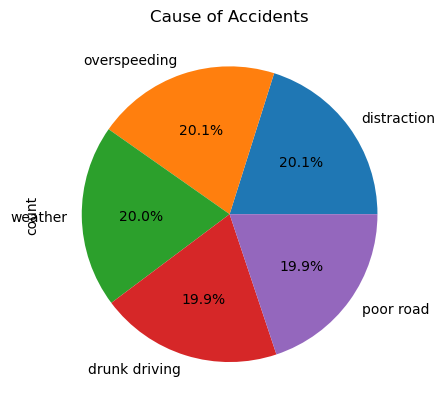

In [20]:
df['cause'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Cause of Accidents')
plt.show()

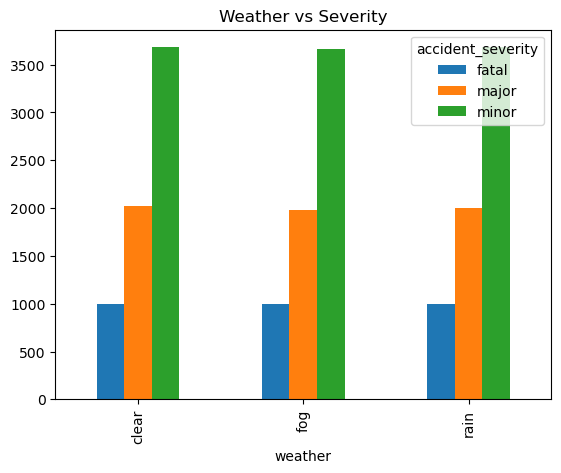

In [21]:
pd.crosstab(df['weather'], df['accident_severity']).plot(kind='bar')
plt.title('Weather vs Severity')
plt.show()

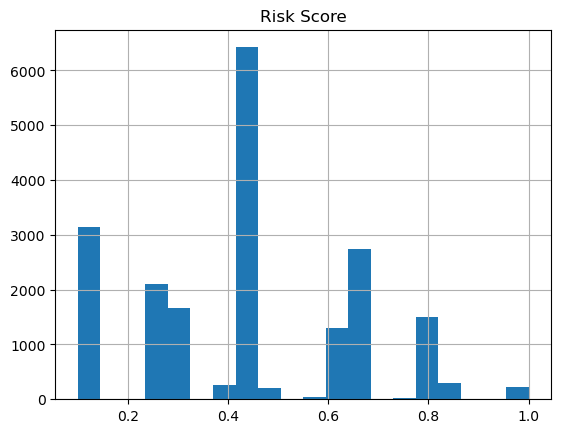

In [22]:
df['risk_score'].hist(bins=20)
plt.title('Risk Score')
plt.show()

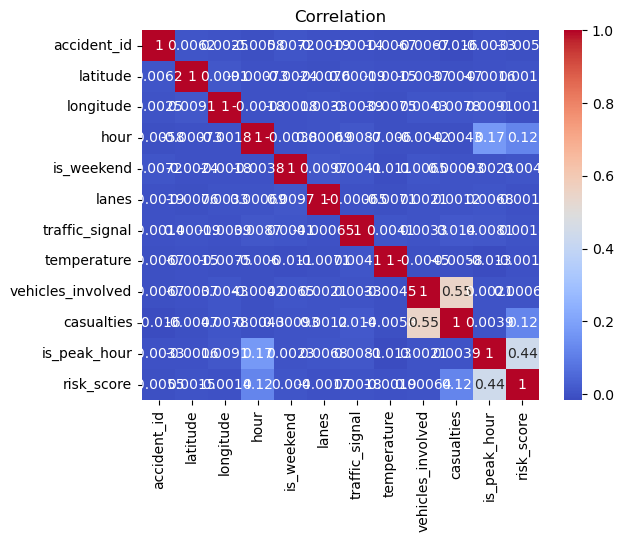

In [23]:
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, cmap='coolwarm')
plt.title('Correlation')
plt.show()

### Data Preprocessing

In [24]:
# drop
df.drop(['accident_id', 'date', 'time'], axis=1, inplace=True)

In [25]:
# fill na
df['festival'] = df['festival'].fillna('None')

In [26]:
# label encoding
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
cols = ['city', 'state', 'day_of_week', 'road_type',
        'weather', 'visibility', 'traffic_density',
        'cause', 'festival', 'accident_severity']
for col in cols:
    df[col] = le.fit_transform(df[col])

In [27]:
# label encoder
severity_encoder = LabelEncoder()
severity_encoder.fit(['fatal', 'major', 'minor'])

LabelEncoder()

In [28]:
#features 
X = df.drop(['accident_severity', 'risk_score'], axis=1)
y_class = df['accident_severity']
y_reg = df['risk_score']

In [29]:
# train test split
from sklearn.model_selection import train_test_split
X_train, X_test, yc_train, yc_test = train_test_split(X, y_class, test_size=0.2, random_state=42)
X_train2, X_test2, yr_train, yr_test = train_test_split(X, y_reg, test_size=0.2, random_state=42)

In [30]:
#scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)
X_train2_sc = scaler.fit_transform(X_train2)
X_test2_sc = scaler.transform(X_test2)

### Model Building

In [31]:
#train classifier
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_sc, yc_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [32]:
#predict
rf_pred = rf_model.predict(X_test_sc)

In [33]:
#Accuracy check
from sklearn.metrics import accuracy_score
print("Accuracy:", accuracy_score(yc_test, rf_pred))

Accuracy: 0.55825


In [41]:
from sklearn.ensemble import GradientBoostingClassifier
gb_model = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb_model.fit(X_train_sc, yc_train)
gb_pred = gb_model.predict(X_test_sc)
print("Accuracy:", accuracy_score(yc_test, gb_pred))

Accuracy: 0.58025


In [42]:
#classification
from sklearn.metrics import classification_report
print(classification_report(yc_test, rf_pred))

              precision    recall  f1-score   support

           0       0.48      0.31      0.38       591
           1       0.33      0.06      0.10      1180
           2       0.58      0.89      0.70      2229

    accuracy                           0.56      4000
   macro avg       0.46      0.42      0.39      4000
weighted avg       0.49      0.56      0.48      4000



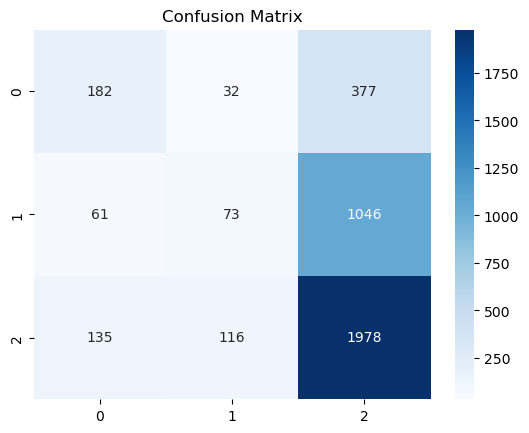

In [43]:
#confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
cm = confusion_matrix(yc_test, rf_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

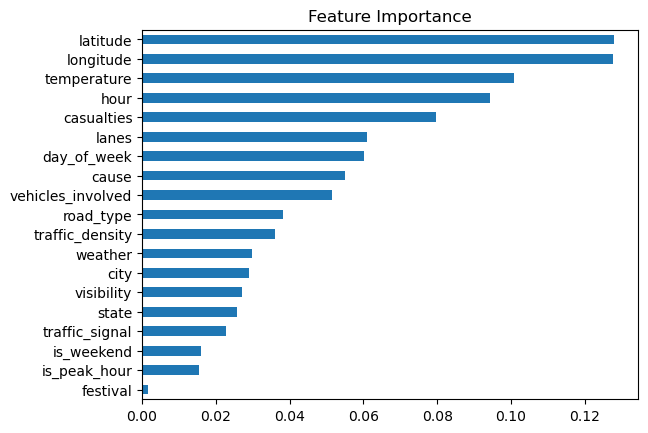

In [44]:
#feature importance
feat_imp = pd.Series(rf_model.feature_importances_, index=X.columns)
feat_imp.sort_values().plot(kind='barh')
plt.title('Feature Importance')
plt.show()

In [45]:
#train risk score model
from sklearn.ensemble import RandomForestRegressor
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(X_train2_sc, yr_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [46]:
#predict
yr_pred = rf_reg.predict(X_test2_sc)

In [47]:
from sklearn.metrics import r2_score, mean_squared_error
print("R2 Score:", r2_score(yr_test, yr_pred))
print("RMSE:", np.sqrt(mean_squared_error(yr_test, yr_pred)))

R2 Score: 0.9126238116128482
RMSE: 0.06370801951089045


In [48]:
import joblib
joblib.dump(rf_model, 'severity_model.pkl')
joblib.dump(rf_reg, 'risk_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(severity_encoder, 'severity_encoder.pkl')
joblib.dump(list(X.columns), 'feature_columns.pkl')
print("All models saved!")

All models saved!
